In [1]:
path = "/Users/eagle/Documents/eagle-labelling/features_pickle/Duramat_no_pool_labels.pkl"
import pandas as pd
df = pd.read_pickle(path)

https://github.com/fhrzn/sml-tech/blob/main/Tasks/Course%20Project/vit-shoe-vs-sandals.
https://github.com/NielsRogge/Transformers-Tutorials/blob/master/SigLIP/Fine_tuning_SigLIP_and_friends_for_multi_label_image_classification.ipynb

In [2]:
df.head()

,features,labels,images,paths,hdbscan_labels,probabilities
5,"[0.20700347, 0.0, 0.0, 0.0, 0.0, 0.0, 0.765714...",-1,"[[[36, 36, 36], [36, 36, 36], [39, 39, 39], [4...",/Users/eagle/Library/CloudStorage/OneDrive-Sha...,2,1.0
9,"[0.04952793, 0.0, 0.0, 0.0, 0.0, 0.0, 0.794440...",-1,"[[[24, 24, 24], [24, 24, 24], [24, 24, 24], [2...",/Users/eagle/Library/CloudStorage/OneDrive-Sha...,2,1.0
11,"[0.27291864, 0.0, 0.0, 0.0, 0.0, 0.0, 0.357645...",0,"[[[26, 26, 26], [26, 26, 26], [26, 26, 26], [2...",/Users/eagle/Library/CloudStorage/OneDrive-Sha...,5,1.0
13,"[0.0066138506, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6499...",-1,"[[[25, 25, 25], [27, 27, 27], [26, 26, 26], [2...",/Users/eagle/Library/CloudStorage/OneDrive-Sha...,2,1.0
16,"[0.39660615, 0.0, 0.0, 0.0, 0.0, 0.0, 0.454769...",5,"[[[97, 97, 97], [99, 99, 99], [101, 101, 101],...",/Users/eagle/Library/CloudStorage/OneDrive-Sha...,-1,0.0


In [3]:
df.labels.value_counts()

labels
 0    4325
-1    2955
 6    1002
 2     898
 4     540
 5     272
 1     112
 3      28
Name: count, dtype: int64

In [4]:
df = df[df.labels >= 0]

In [5]:
df.labels.value_counts()

labels
0    4325
6    1002
2     898
4     540
5     272
1     112
3      28
Name: count, dtype: int64

In [6]:
labels = df.labels.unique()
len(labels)

7

In [7]:
from transformers import ViTFeatureExtractor, ViTForImageClassification
from transformers import TrainingArguments, Trainer


/Users/eagle/GitCode/venv-metal-gitcode/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [8]:
import torch
model_ckpt = 'google/vit-base-patch16-224-in21k'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
extractor = ViTFeatureExtractor.from_pretrained(model_ckpt)   #problem_type="multi_label_classification"  --> label torch.tensor([[1, 1, 0, 0]])
device

/Users/eagle/GitCode/venv-metal-gitcode/lib/python3.9/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


device(type='cpu')

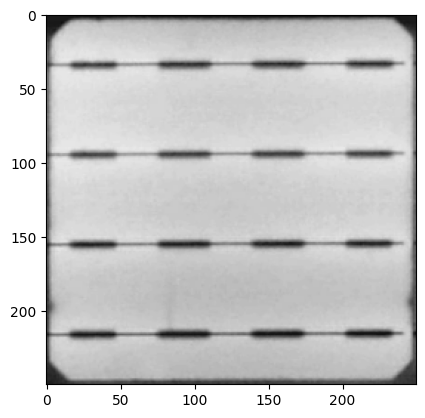

In [9]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[0].images)

In [10]:
ex = extractor(df.iloc[0].images, return_tensors='pt')
ex

{'pixel_values': tensor([[[[-0.7961, -0.7961, -0.7961,  ..., -0.7961, -0.7961, -0.7961],
          [-0.7961, -0.7961, -0.7961,  ..., -0.7961, -0.7961, -0.7961],
          [-0.7961, -0.7961, -0.7961,  ..., -0.7961, -0.7961, -0.7961],
          ...,
          [-0.7176, -0.6863, -0.7020,  ..., -0.5922, -0.5765, -0.5765],
          [-0.7333, -0.7333, -0.7490,  ..., -0.5922, -0.5922, -0.5922],
          [-0.7647, -0.7569, -0.7647,  ..., -0.5843, -0.5922, -0.5922]],

         [[-0.7961, -0.7961, -0.7961,  ..., -0.7961, -0.7961, -0.7961],
          [-0.7961, -0.7961, -0.7961,  ..., -0.7961, -0.7961, -0.7961],
          [-0.7961, -0.7961, -0.7961,  ..., -0.7961, -0.7961, -0.7961],
          ...,
          [-0.7176, -0.6863, -0.7020,  ..., -0.5922, -0.5765, -0.5765],
          [-0.7333, -0.7333, -0.7490,  ..., -0.5922, -0.5922, -0.5922],
          [-0.7647, -0.7569, -0.7647,  ..., -0.5843, -0.5922, -0.5922]],

         [[-0.7961, -0.7961, -0.7961,  ..., -0.7961, -0.7961, -0.7961],
          [-0

In [11]:
def batch_transform(examples):
    # take a list of PIL images and turn into pixel values
    inputs = extractor([x for x in examples['images']], return_tensors='pt')
    # add the labels in
    inputs['labels'] = examples['labels']
    
    return inputs

In [12]:
df_transformed = batch_transform(df)

In [13]:
df_transformed.keys()

dict_keys(['pixel_values', 'labels'])

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_val, y_train, y_val = train_test_split(df_transformed.pixel_values, df_transformed.labels, test_size=.3, random_state=42)

In [16]:
X_train.shape, X_val.shape

(torch.Size([5023, 3, 224, 224]), torch.Size([2154, 3, 224, 224]))

In [17]:
from datasets import Dataset
ds_train = Dataset.from_dict({
                "image": X_train,
                "labels": y_train
            })
ds_train

Dataset({
    features: ['image', 'labels'],
    num_rows: 5023
})

In [18]:
ds_val = Dataset.from_dict({
                "image": X_val,
                "labels": y_val
            })
ds_val

Dataset({
    features: ['image', 'labels'],
    num_rows: 2154
})

In [19]:
model = ViTForImageClassification.from_pretrained(model_ckpt,
                                                 num_labels=len(labels),
                                                 id2label={str(i): str(c) for i, c in enumerate(labels)},
                                                 label2id={str(c): str(i) for i, c in enumerate(labels)})
model = model.to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
batch_size = 16
logging_steps = len(X_train) // batch_size
training_args = TrainingArguments(output_dir='./working/',
                                 per_device_train_batch_size=batch_size,
                                 per_device_eval_batch_size=batch_size,
                                 evaluation_strategy='epoch',
                                 save_strategy='epoch',
                                 num_train_epochs=2,
                                 fp16=True if torch.cuda.is_available() else False,
                                 logging_steps=logging_steps,
                                 learning_rate=1e-5,
                                 save_total_limit=2,
                                 remove_unused_columns=False,
                                 push_to_hub=False,
                                 load_best_model_at_end=True)

In [21]:
from sklearn.metrics import f1_score, accuracy_score
from datasets import load_metric

def collate_fn(examples):
    return {
        'pixel_values': torch.stack([torch.tensor(x['image']) for x in examples]),
        'labels': torch.tensor([x['labels'] for x in examples])
    }

metric = load_metric('accuracy')
def compute_metrics(p):
    labels = p.label_ids
    preds = p.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {
        'accuracy': acc,
        'f1': f1
    }

/var/folders/s4/l6k_zf9573j5vh_2y0qy50sc0000gx/T/ipykernel_12988/412919450.py:10: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  metric = load_metric('accuracy')
/Users/eagle/GitCode/venv-metal-gitcode/lib/python3.9/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.0/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


In [22]:
trainer = Trainer(model=model,
                 args=training_args,
                 data_collator=collate_fn,
                 compute_metrics=compute_metrics,
                 train_dataset=ds_train,
                 eval_dataset=ds_val,
                 tokenizer=extractor)

In [23]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.688800,0.391721,0.918756,0.900799
2,0.318800,0.300952,0.948468,0.941875


In [32]:
predictions = trainer.predict(ds_val)
predictions.metrics

{'test_loss': 0.3009522259235382,
 'test_accuracy': 0.9484679665738162,
 'test_f1': 0.9418753368012636,
 'test_runtime': 96.4335,
 'test_samples_per_second': 22.337,
 'test_steps_per_second': 1.4}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

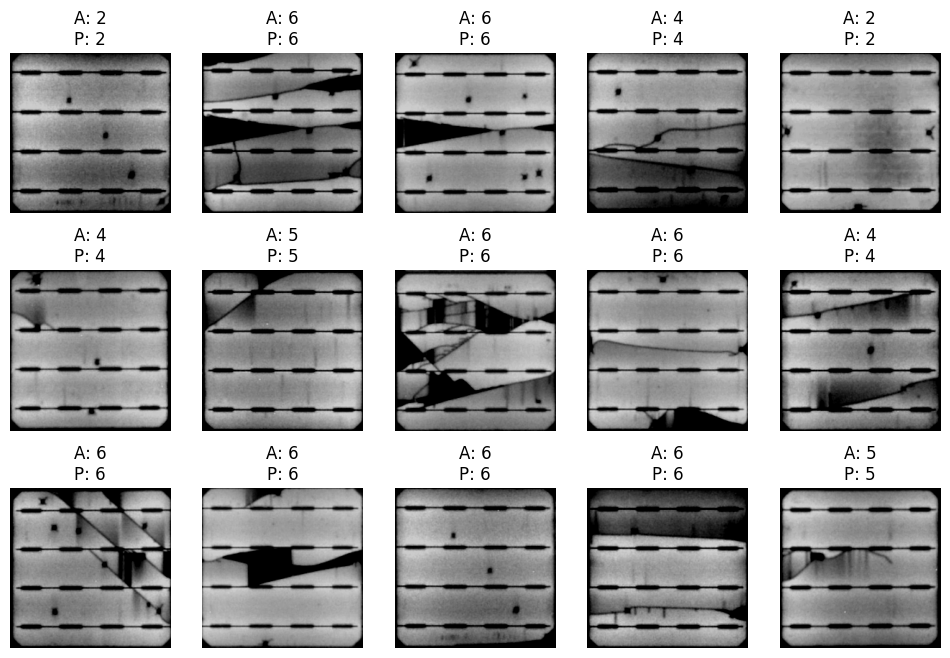

In [33]:
# plot samples
import numpy as np
fig, ax = plt.subplots(3, 5, sharex=True, sharey=True, figsize=(12,8))
for i in range(3):
    for j in range(5):
        while True:
            idx = np.random.choice(ds_val.shape[0], 1, replace=False)
            if ds_val[int(idx[0])]["labels"] > 0:
                break
        s = ds_val[int(idx[0])]
        ax[i,j].imshow(np.transpose(s['image'], (1,2,0)))
        ax[i,j].set_title(f"A: {s['labels']}\nP: {predictions.label_ids[int(idx[0])]}")
        ax[i,j].axis('off')

plt.show()

In [26]:
path = "/Users/eagle/Documents/eagle-labelling/features_pickle/Infinity_all_no_pool_labels.pkl"
df_inf = pd.read_pickle(path)
df_inf = df_inf[df_inf.labels >= 0]
df_inf = df_inf[df_inf.labels <= 6]
df_inf_transformed = batch_transform(df_inf)
ds_test = Dataset.from_dict({
                "image": df_inf_transformed.pixel_values,
                "labels": df_inf_transformed.labels
            })
ds_test

Dataset({
    features: ['image', 'labels'],
    num_rows: 2354
})

In [27]:
df_inf.labels.value_counts()

labels
0    2112
2     156
1      39
3      21
4      15
5      11
Name: count, dtype: int64

In [28]:
predictions = trainer.predict(ds_test)
predictions.metrics

{'test_loss': 0.6249406933784485,
 'test_accuracy': 0.9337298215802888,
 'test_f1': 0.9210739180272408,
 'test_runtime': 106.6612,
 'test_samples_per_second': 22.07,
 'test_steps_per_second': 1.388}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

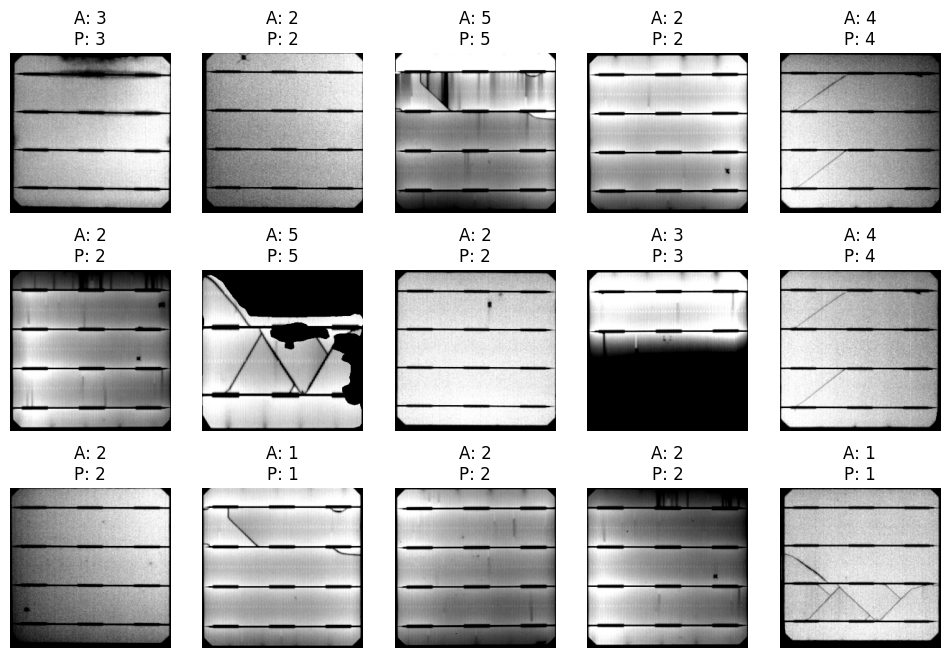

In [31]:
# plot samples
import numpy as np
fig, ax = plt.subplots(3, 5, sharex=True, sharey=True, figsize=(12,8))
for i in range(3):
    for j in range(5):
        while True:
            idx = np.random.choice(ds_test.shape[0], 1, replace=False)
            if ds_test[int(idx[0])]["labels"] > 0:
                break
        s = ds_test[int(idx[0])]
        ax[i,j].imshow(np.transpose(s['image'], (1,2,0)))
        ax[i,j].set_title(f"A: {s['labels']}\nP: {predictions.label_ids[int(idx[0])]}")
        ax[i,j].axis('off')

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_title'

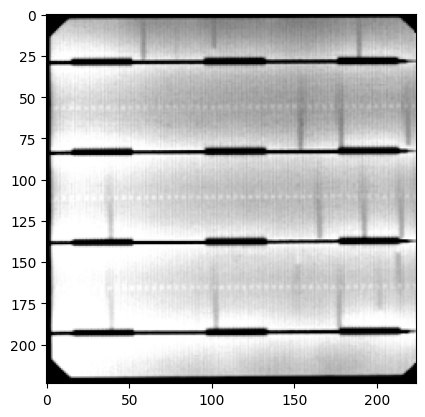

In [34]:
# plot samples
for i in range(ds_test.shape[0]):
    if ds_test[i]['labels'] != predictions.label_ids[i]:
        plt.imshow(np.transpose(ds_test[i]['image'], (1,2,0)))
        plt.set_title(f"A: {ds_test[i]['labels']}\nP: {predictions.label_ids[i]}")
        plt.show()